In [28]:
# Autoreload extension for Jupyter notebooks
%load_ext autoreload
%autoreload 2

# Magic commands for inline plotting and high-res figures
%matplotlib inline
%config InlineBackend.figure_format ='retina'

# Standard library imports
import os
import sys

# Third-party library imports
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Add the parent directory to sys.path
from pathlib import Path
sys.path.append(str(Path(os.getcwd()).parent.parent))

# Pandas configurations
pd.set_option('display.max_rows', 1000)
idx = pd.IndexSlice

# rsmf figure setup
import rsmf
import matplotlib
from matplotlib.backends.backend_pgf import FigureCanvasPgf

FIG_FORMATTER = rsmf.setup(
    r"\documentclass[a4paper,twocolumn,10pt,unpublished]{quantumarticle}"
)
COLORS = plt.get_cmap("tab10")

plt.rcParams.update({
    "axes.prop_cycle": plt.cycler("color", plt.cm.tab10.colors),
    "xtick.direction": "out",
    "ytick.direction": "out",
    "xtick.major.size": 3,
    "ytick.major.size": 3,
    "figure.constrained_layout.use": True, 
    "figure.constrained_layout.h_pad": 0.02,
    "figure.constrained_layout.w_pad": 0.02,
    "figure.constrained_layout.hspace": 0.01,
    "figure.constrained_layout.wspace": 0.01,
    "legend.framealpha": 0.5,
})

# Jupyter inline display
matplotlib.backend_bases.register_backend("pdf", FigureCanvasPgf)
matplotlib.use("module://matplotlib_inline.backend_inline")

from simulations.analysis.plotting_helpers import error_band_plot, load_data, get_lower_envelope

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


## Configuration

Configure the gap proxy method and parameters below. Available methods:
- `'mlf'` - Most-likely-first (deterministic)
- `'wr'` - Weighted-random (stochastic)
- `'mlfa'` - Most-likely-first-adaptive (adaptive deterministic)
- `'wra'` - Weighted-random-adaptive (adaptive stochastic)
- `'random'` - Uniform random sampling
- `'nearby'` - Nearby logical classes only (no `num_logical_classes` needed)

For `'random'` method, you can optionally specify `COVERAGE_FRACTION` to restrict sampling to the most likely logical errors (requires pre-computed distribution).

In [29]:
# ==============================================================================
# CONFIGURATION - Modify these parameters to change the analysis
# ==============================================================================

# Gap proxy method: 'mlf', 'wr', 'mlfa', 'wra', 'random', 'nearby'
GAP_PROXY_METHOD = "random"

# Number of logical classes explored (not used for 'nearby')
NUM_LOGICAL_CLASSES = 24

# Coverage fraction for 'random' method (None or 1.0 = no restriction)
COVERAGE_FRACTION = None

# ==============================================================================
# Load data based on configuration
# ==============================================================================

# Method display names for plot titles
METHOD_DISPLAY_NAMES = {
    "mlf": "Most-Likely-First",
    "wr": "Weighted-Random",
    "mlfa": "Most-Likely-First-Adaptive",
    "wra": "Weighted-Random-Adaptive",
    "random": "Random",
    "nearby": "Nearby",
}


def build_dataset_name(method: str, num_classes: int, coverage: float | None = None) -> str:
    """Build dataset name based on method and parameters."""
    if method == "nearby":
        return "bb_gap_proxy"
    
    base_name = f"bb_gap_proxy_{method}_{num_classes}"
    
    # Add coverage suffix for 'random' method
    if method == "random" and coverage is not None and coverage < 1.0:
        base_name += f"_cov{coverage}"
    
    return base_name


# Build dataset name based on method
dataset_name = build_dataset_name(GAP_PROXY_METHOD, NUM_LOGICAL_CLASSES, COVERAGE_FRACTION)

# Load the gap_proxy data
df_ps_dict = load_data([dataset_name])

# Display configuration and available keys
print(f"Configuration:")
print(f"  Method: {GAP_PROXY_METHOD} ({METHOD_DISPLAY_NAMES[GAP_PROXY_METHOD]})")
if GAP_PROXY_METHOD != "nearby":
    print(f"  Num logical classes: {NUM_LOGICAL_CLASSES}")
if GAP_PROXY_METHOD == "random" and COVERAGE_FRACTION is not None and COVERAGE_FRACTION < 1.0:
    print(f"  Coverage fraction: {COVERAGE_FRACTION}")
print(f"  Dataset: {dataset_name}")
print(f"\nAvailable metrics:")
for key in sorted(df_ps_dict.keys()):
    print(f"  - {key}")

Configuration:
  Method: random (Random)
  Num logical classes: 24
  Dataset: bb_gap_proxy_random_24

Available metrics:
  - gap_proxy
  - gap_proxy_10
  - gap_proxy_11
  - gap_proxy_12
  - gap_proxy_13
  - gap_proxy_14
  - gap_proxy_15
  - gap_proxy_16
  - gap_proxy_17
  - gap_proxy_18
  - gap_proxy_19
  - gap_proxy_2
  - gap_proxy_20
  - gap_proxy_21
  - gap_proxy_22
  - gap_proxy_23
  - gap_proxy_24
  - gap_proxy_3
  - gap_proxy_4
  - gap_proxy_5
  - gap_proxy_6
  - gap_proxy_7
  - gap_proxy_8
  - gap_proxy_9


In [30]:
# Extract the N values from the keys
# gap_proxy corresponds to N=NUM_LOGICAL_CLASSES
# gap_proxy_i corresponds to N=i

def get_N_from_key(key: str, max_N: int) -> int:
    """Extract N value from gap_proxy key."""
    if key == "gap_proxy":
        return max_N
    elif key.startswith("gap_proxy_"):
        return int(key.split("_")[-1])
    else:
        raise ValueError(f"Unknown key format: {key}")

# Build mapping from N to DataFrame
N_to_df = {}
for key in df_ps_dict.keys():
    N = get_N_from_key(key, NUM_LOGICAL_CLASSES)
    N_to_df[N] = df_ps_dict[key]

# Sort by N
N_values = sorted(N_to_df.keys())
print(f"Available N values: {N_values}")
print(f"Total: {len(N_values)} different N values")

Available N values: [2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24]
Total: 23 different N values


In [31]:
def create_mask(
    df: pd.DataFrame, value_col: str = "p_fail", error_col: str = "delta_p_fail"
) -> np.ndarray:
    """Create a mask for lower envelope based on upper bound of p_fail."""
    upper_bound = df[value_col] + df[error_col]
    mask = np.ones(len(upper_bound), dtype=bool)
    non_decreasing = upper_bound.iloc[1:].values >= upper_bound.iloc[:-1].values
    mask[1:] = ~non_decreasing
    return mask


def plot_plog_vs_pabort_by_N(
    N_to_df: dict[int, pd.DataFrame],
    n: int,
    p: float,
    N_values: list[int] | None = None,
    ax: plt.Axes | None = None,
    cmap_name: str = "viridis",
    tol: float = 0.8,
):
    """
    Plot logical error rate vs abort rate for different N values.
    
    Parameters
    ----------
    N_to_df : dict[int, pd.DataFrame]
        Mapping from N to post-selection DataFrame.
    n : int
        Code size parameter.
    p : float
        Physical error probability.
    N_values : list[int], optional
        Specific N values to plot. If None, uses all available N values.
    ax : plt.Axes, optional
        Axes to plot on. If None, creates new figure.
    cmap_name : str
        Colormap name for coloring different N values.
    tol : float, optional
        Tolerance for relative error.
    
    Returns
    -------
    fig, ax
        Figure and axes objects.
    """
    T = {144: 12, 72: 6}[n]
    
    # Determine which N values to plot
    all_N = sorted(N_to_df.keys())
    
    if N_values is not None:
        N_to_plot = [N for N in N_values if N in all_N]
    else:
        N_to_plot = all_N
    
    # Create figure if not provided
    if ax is None:
        fig = FIG_FORMATTER.figure(wide=True, width_ratio=0.49, aspect_ratio=0.8)
        ax = fig.add_subplot()
    else:
        fig = ax.get_figure()
    
    cmap = plt.get_cmap(cmap_name)
    
    for i, N in enumerate(N_to_plot):
        df_ps = N_to_df[N]
        
        try:
            df_ps_d = df_ps.loc[(n, T, p)].reset_index().sort_values("p_abort")
        except KeyError:
            print(f"Warning: No data for N={N}, n={n}, T={T}, p={p}")
            continue
        
        df_ps_d = df_ps_d[create_mask(df_ps_d)]
        
        # Filter for relative error < 0.8
        df_ps_d = df_ps_d[df_ps_d["delta_p_fail"] / df_ps_d["p_fail"] < tol]
        
        color = cmap(i / max(len(N_to_plot) - 1, 1))
        label = rf"$N_\mathrm{{class}} = {N}$"
        
        p_abort = df_ps_d["p_abort"].values
        p_fail = df_ps_d["p_fail"].values
        delta_p_fail = df_ps_d["delta_p_fail"].values
        
        error_band_plot(p_abort, p_fail, delta_p_fail, ax=ax, color=color, label=label)
    
    code_params = f"$[[144, 12, 12]]$ BB Code" if n == 144 else f"$[[72, 12, 6]]$"
    ax.set_title(rf"{code_params}, $p = {p}$", fontsize=10)
    ax.set_xlim(0, 1)
    ax.set_xticks(np.arange(0, 1.1, 0.2))
    ax.set_yscale("log")
    ax.set_xlabel(r"Abort rate, $p_\mathrm{abort}$")
    ax.set_ylabel(r"Logical error rate, $p_\mathrm{log}$")
    ax.legend(fontsize=7, loc="lower left")
    
    return fig, ax

In [32]:
from statsmodels.nonparametric.smoothers_lowess import lowess


def get_plog_at_abort_rate(
    df_ps: pd.DataFrame,
    target_abort_rate: float,
) -> tuple[float, float]:
    """
    Get logical error rate at a target abort rate via interpolation.

    Parameters
    ----------
    df_ps : pd.DataFrame
        Post-selection DataFrame with p_abort, p_fail, delta_p_fail columns.
    target_abort_rate : float
        Target abort rate to interpolate.

    Returns
    -------
    p_fail : float
        Interpolated logical error rate.
    delta_p_fail : float
        Interpolated error bound.
    """
    df_sorted = df_ps.sort_values("p_abort").reset_index(drop=True)
    p_abort = df_sorted["p_abort"].values
    p_fail = df_sorted["p_fail"].values
    delta_p_fail = df_sorted["delta_p_fail"].values

    # Find the closest abort rate <= target
    valid_idx = np.where(p_abort <= target_abort_rate)[0]
    if len(valid_idx) == 0:
        # All abort rates are above target, use the smallest
        idx = 0
    else:
        idx = valid_idx[-1]  # Largest index with p_abort <= target

    return p_fail[idx], delta_p_fail[idx]


def plot_plog_vs_N(
    N_to_df: dict[int, pd.DataFrame],
    n: int,
    p: float,
    target_abort_rate: float,
    ax: plt.Axes | None = None,
    color=None,
    label: str | None = None,
    marker: str = "o",
    lowess_frac: float = 0.67,
):
    """
    Plot logical error rate vs N for a fixed abort rate with LOWESS fitting.

    Parameters
    ----------
    N_to_df : dict[int, pd.DataFrame]
        Mapping from N to post-selection DataFrame.
    n : int
        Code size parameter.
    p : float
        Physical error probability.
    target_abort_rate : float
        Fixed abort rate for comparison.
    ax : plt.Axes, optional
        Axes to plot on. If None, creates new figure.
    color : optional
        Color for the plot.
    label : str, optional
        Label for the legend.
    marker : str
        Marker style.
    lowess_frac : float
        Fraction of data used for LOWESS smoothing (0 to 1).

    Returns
    -------
    fig, ax
        Figure and axes objects.
    """
    T = {144: 12, 72: 6}[n]

    if ax is None:
        fig = FIG_FORMATTER.figure(wide=True, width_ratio=0.49, aspect_ratio=0.8)
        ax = fig.add_subplot()
    else:
        fig = ax.get_figure()

    N_values = []
    p_fail_values = []
    delta_p_fail_values = []

    for N in sorted(N_to_df.keys()):
        df_ps = N_to_df[N]

        try:
            df_ps_d = df_ps.loc[(n, T, p)].reset_index()
        except KeyError:
            continue

        p_fail, delta_p_fail = get_plog_at_abort_rate(df_ps_d, target_abort_rate)

        N_values.append(N)
        p_fail_values.append(p_fail)
        delta_p_fail_values.append(delta_p_fail)

    N_values = np.array(N_values)
    p_fail_values = np.array(p_fail_values)
    delta_p_fail_values = np.array(delta_p_fail_values)

    # Plot data points with error bars (no connecting line)
    ax.errorbar(
        N_values,
        p_fail_values,
        yerr=delta_p_fail_values,
        marker=marker,
        color=color,
        label=label,
        capsize=2,
        capthick=1,
        markersize=4,
        linestyle="none",
    )

    # Add LOWESS fitting line (fit in log space for log-scale y-axis)
    log_p_fail = np.log(p_fail_values)
    lowess_result = lowess(log_p_fail, N_values, frac=lowess_frac, return_sorted=True)
    N_smooth = lowess_result[:, 0]
    p_fail_smooth = np.exp(lowess_result[:, 1])

    ax.plot(N_smooth, p_fail_smooth, color=color, linestyle="-")

    return fig, ax, (N_values, p_fail_values, delta_p_fail_values)

## (a) Comparison of gap proxy methods

Compare failure rate vs number of explored classes for different gap proxy methods at fixed abort rates.

In [33]:
# Compare gap proxy methods: failure rate vs number of explored classes
# 3-column figure with different abort rates

# Fixed parameters
n = 144
p = 0.003
T = {144: 12, 72: 6}[n]
MAX_N = 24
TARGET_ABORT_RATES = [0.1, 0.2, 0.3]

# Methods to compare: list of (method_key, method_name, coverage_fraction)
# method_key is used for loading data, method_name is used for display
METHODS_TO_COMPARE = [
    ("random", "random", None),
    ("random-0.5", "random", 0.5),  # random with coverage=0.5
    ("mlf", "mlf", None),
    ("wr", "wr", None),
    ("mlfa", "mlfa", None),
    ("wra", "wra", None),
]

# Method display names and colors
METHOD_LABELS = {
    "random": "random",
    "random-0.5": "random-0.5",
    "mlf": "most-likely-first",
    "wr": "weighted-random",
    "mlfa": "adaptive-most-likely-first",
    "wra": "adaptive-weighted-random",
}
METHOD_MARKERS = {
    "random": "o",
    "random-0.5": "o",
    "mlf": "s",
    "wr": "^",
    "mlfa": "D",
    "wra": "v",
}

# Load data for all available methods
method_data = {}
for method_key, method_name, coverage in METHODS_TO_COMPARE:
    dataset_name = build_dataset_name(method_name, MAX_N, coverage)
    try:
        df_ps_dict = load_data([dataset_name])
        if df_ps_dict:
            # Build N_to_df mapping for this method
            N_to_df_method = {}
            for key in df_ps_dict.keys():
                N = get_N_from_key(key, MAX_N)
                N_to_df_method[N] = df_ps_dict[key]
            method_data[method_key] = N_to_df_method
            print(f"Loaded {method_key}: {len(N_to_df_method)} N values (dataset: {dataset_name})")
    except Exception as e:
        print(f"Skipping {method_key}: {e}")

print(f"\nAvailable methods: {list(method_data.keys())}")

Loaded random: 23 N values (dataset: bb_gap_proxy_random_24)
Loaded random-0.5: 23 N values (dataset: bb_gap_proxy_random_24_cov0.5)
Loaded mlf: 23 N values (dataset: bb_gap_proxy_mlf_24)
Loaded wr: 23 N values (dataset: bb_gap_proxy_wr_24)
Loaded mlfa: 23 N values (dataset: bb_gap_proxy_mlfa_24)
Loaded wra: 23 N values (dataset: bb_gap_proxy_wra_24)

Available methods: ['random', 'random-0.5', 'mlf', 'wr', 'mlfa', 'wra']


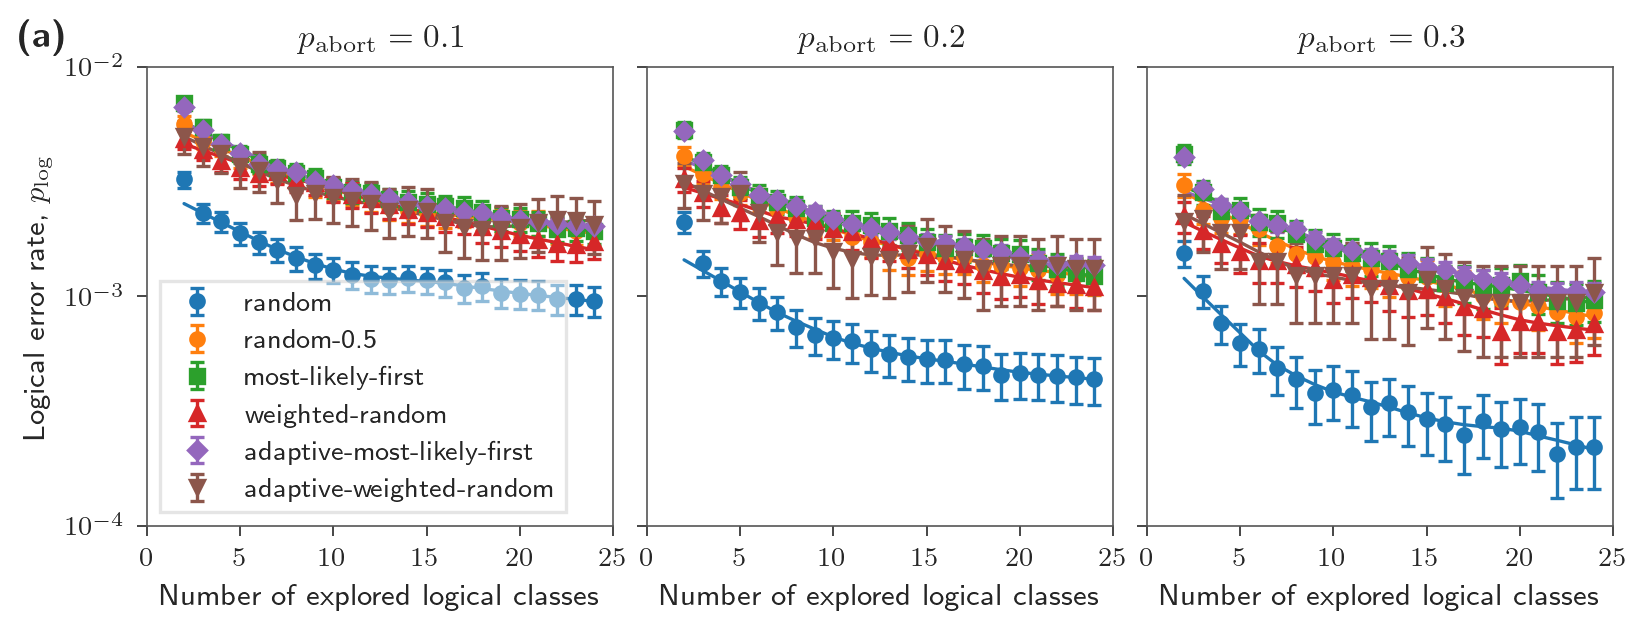

In [34]:
# Create 3-column figure using rsmf
fig = FIG_FORMATTER.figure(wide=True, aspect_ratio=0.37)
axes = fig.subplots(1, 3, sharey=True)

cmap = plt.get_cmap("tab10")

for col, target_abort in enumerate(TARGET_ABORT_RATES):
    ax = axes[col]
    
    for i, (method_key, N_to_df_method) in enumerate(method_data.items()):
        color = cmap(i)
        label = METHOD_LABELS.get(method_key, method_key)
        marker = METHOD_MARKERS.get(method_key, "o")
        
        _, _, (N_values, p_fail_values, delta_p_fail_values) = plot_plog_vs_N(
            N_to_df_method,
            n=n,
            p=p,
            target_abort_rate=target_abort,
            ax=ax,
            color=color,
            label=label if col == 0 else None,  # Only label in first column
            marker=marker,
            lowess_frac=0.4,
        )
    
    ax.set_title(rf"$p_{{\mathrm{{abort}}}} = {target_abort}$", fontsize=10)
    ax.set_xlabel(r"Number of explored logical classes")
    if col == 0:
        ax.set_ylabel(r"Logical error rate, $p_\mathrm{log}$")
    ax.set_yscale("log")
    
    ax.set_xlim(0, MAX_N + 1)
    ax.set_ylim(1e-4, 1e-2)

# Add legend to the first subplot
axes[0].legend(fontsize=8)

fig.text(
    0,
    1,
    r"\textbf{(a)}",
    fontsize=11,
    in_layout=False,
    transform=fig.transFigure,
    verticalalignment="top",
)

fig.savefig("figs/bb_gap_proxy_method_comparison.pdf")

## (b) Logical error rate vs abort rate for 'random' method

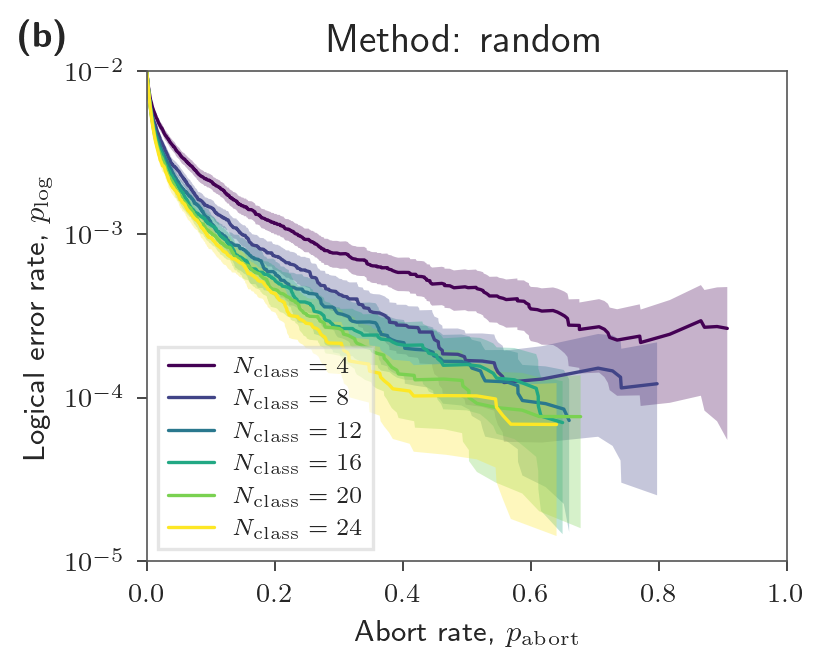

In [35]:
# Plot for n=144, p=0.003 with 'random' method
n = 144
p = 0.003
T = {144: 12, 72: 6}[n]
MAX_N = 24

# Load 'random' method data (without coverage restriction)
dataset_name = build_dataset_name("random", MAX_N, coverage=None)
df_ps_dict_random = load_data([dataset_name])

# Build N_to_df mapping for random method
N_to_df_random = {}
for key in df_ps_dict_random.keys():
    N = get_N_from_key(key, MAX_N)
    N_to_df_random[N] = df_ps_dict_random[key]

fig, ax = plot_plog_vs_pabort_by_N(
    N_to_df_random,
    n=n,
    p=p,
    N_values=np.arange(4, 25, 4),
)

ax.set_title("Method: random")  # Remove title
ax.set_ylim(1e-5, 1e-2)
ax.legend(fontsize=7, loc="lower left")

fig.text(
    0,
    1,
    r"\textbf{(b)}",
    fontsize=11,
    in_layout=False,
    transform=fig.transFigure,
    verticalalignment="top",
)

fig.savefig("figs/bb_gap_proxy_random_plog_vs_pabort.pdf")

## (c) Logical error distribution

Note: The logical error distribution is stored in the simulation data directory for methods that use it (mlf, wr, mlfa, wra).

Loaded distribution from: /home/shlee/Projects/2025/ldpc-post-selection/simulations/data/logical_error_distributions/bb_minsum_iter30_lsd0/n144_T12_p0.003.npy
Total shots: 4,096,000
Logical error rate: 0.9544%
Nonzero error classes: 3949 / 4095


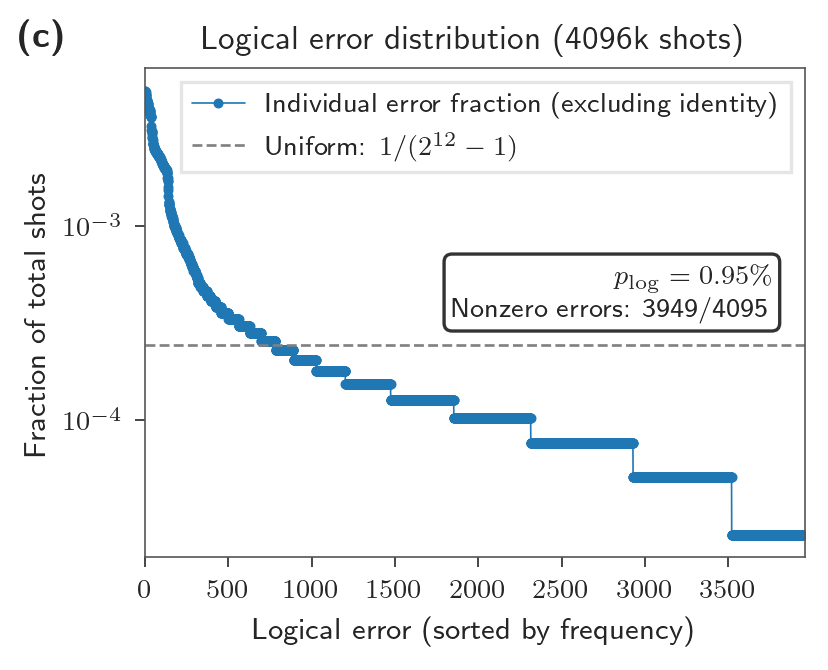

In [36]:
# Load and plot the logical error distribution
n = 144
p = 0.003
T = {144: 12, 72: 6}[n]

# Path to the distribution file (shared location independent of gap proxy method)
data_dir = Path(os.getcwd()).parent.parent / "data"
dist_dir = data_dir / "logical_error_distributions" / "bb_minsum_iter30_lsd0"
dist_path = dist_dir / f"n{n}_T{T}_p{p}.npy"

# Check if distribution exists
if not dist_path.exists():
    print(f"Distribution file not found: {dist_path}")
    print("This is expected for methods that don't use pre-computed distributions (e.g., 'nearby', 'random').")
else:
    # Load distribution
    dist = np.load(dist_path)
    total_shots = dist.sum()

    # Sort by frequency (excluding index 0 = correct decoding)
    error_dist = dist[1:]  # Exclude correct decoding
    error_indices = np.arange(1, len(dist))  # 1 to 2^k - 1

    # Sort in descending order
    sorted_order = np.argsort(error_dist)[::-1]
    sorted_counts = error_dist[sorted_order]
    sorted_indices = error_indices[sorted_order]

    # Compute cumulative fraction
    sorted_fractions = sorted_counts / total_shots
    cumulative_fractions = np.cumsum(sorted_fractions)

    # Only plot non-zero errors
    nonzero_mask = sorted_counts > 0
    sorted_counts_nz = sorted_counts[nonzero_mask]
    sorted_fractions_nz = sorted_fractions[nonzero_mask]
    cumulative_fractions_nz = cumulative_fractions[nonzero_mask]
    rank = np.arange(1, len(sorted_counts_nz) + 1)
    logical_error_rate = 1 - dist[0] / total_shots

    # Create figure
    fig = FIG_FORMATTER.figure(wide=True, width_ratio=0.49, aspect_ratio=0.8)
    ax = fig.add_subplot()

    # Plot individual error fractions
    ax.semilogy(rank, sorted_fractions_nz / logical_error_rate, 'o-', markersize=2, linewidth=0.5, label="Individual error fraction (excluding identity)")

    # Add reference lines
    ax.axhline(1 / (len(dist) - 1), color='gray', linestyle='--', linewidth=0.8, label=rf"Uniform: $1/(2^{{{int(np.log2(len(dist)))}}} - 1)$")

    # Formatting
    ax.set_title(r"Logical error distribution (4096k shots)", fontsize=10)
    ax.set_xlabel(r"Logical error (sorted by frequency)")
    ax.set_ylabel(r"Fraction of total shots")
    ax.set_xlim(0, len(sorted_counts_nz) + 10)
    ax.legend(fontsize=8)

    # Add statistics as text (escape % for LaTeX)
    ax.text(
        0.95, 0.6,
        rf"$p_{{\mathrm{{log}}}} = {logical_error_rate*100:.2f}\%$" + "\n" +
        rf"Nonzero errors: {len(sorted_counts_nz)}/{len(dist)-1}",
        transform=ax.transAxes,
        fontsize=8,
        verticalalignment='top',
        horizontalalignment='right',
        bbox=dict(boxstyle='round', facecolor='white', alpha=0.8),
    )

    fig.text(
        0,
        1,
        r"\textbf{(c)}",
        fontsize=11,
        in_layout=False,
        transform=fig.transFigure,
        verticalalignment="top",
    )

    fig.savefig("figs/bb_gap_proxy_error_distribution.pdf")
    
    print(f"Loaded distribution from: {dist_path}")
    print(f"Total shots: {total_shots:,}")
    print(f"Logical error rate: {logical_error_rate:.4%}")
    print(f"Nonzero error classes: {len(sorted_counts_nz)} / {len(dist)-1}")